In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer

In [4]:
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [5]:
news_df["date"] = pd.to_datetime(
    news_df["date"],
    format="mixed",
    utc=True
)

CREATE DATE-ONLY COLUMN
We only need trading day

In [ ]:
news_df["date_only"] = news_df["date"].dt.date

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
news_df["sentiment"] = news_df["headline"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [ ]:
news_df[["headline", "sentiment"]].head()

,headline,sentiment
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


### Sentiment Analysis Insight

VADER sentiment analysis was applied to financial news headlines to generate compound sentiment scores ranging from -1 to +1. Positive scores indicate optimistic market sentiment, while negative scores represent pessimistic sentiment.

In [ ]:
aapl = pd.read_csv("../data/raw/AAPL.csv")

aapl.head()


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [ ]:
aapl["Date"] = pd.to_datetime(aapl["Date"])

aapl["date_only"] = aapl["Date"].dt.date

In [ ]:
aapl["daily_return"] = (
    aapl["Close"].pct_change()
) * 100

In [35]:
aapl[["Date", "Close", "daily_return"]].head()

,Date,Close,daily_return
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959


In [36]:
aapl_news = news_df[
    news_df["stock"] == "AAPL"
]

In [37]:
daily_sentiment = (
    aapl_news.groupby("date_only")["sentiment"]
    .mean()
    .reset_index()
)

In [38]:
merged = pd.merge(
    daily_sentiment,
    aapl[["date_only", "daily_return"]],
    on="date_only",
    how="inner"
)

In [39]:
merged.head()

,date_only,sentiment,daily_return
0,2020-03-09,-0.302067,-7.909217
1,2020-03-10,-0.090787,7.202157
2,2020-03-11,-0.023850,-3.473025
3,2020-03-12,-0.078360,-9.875496
4,2020-03-13,-0.059727,11.980808


##CALCULATE PEARSON CORRELATION

In [40]:
correlation = merged["sentiment"].corr(
    merged["daily_return"]
)

print("Correlation:", correlation)

Correlation: 0.08915625547933331



THE ABOVE OUTPUT SHOWS THERE IS STRONG POSITIVE CORRELATION

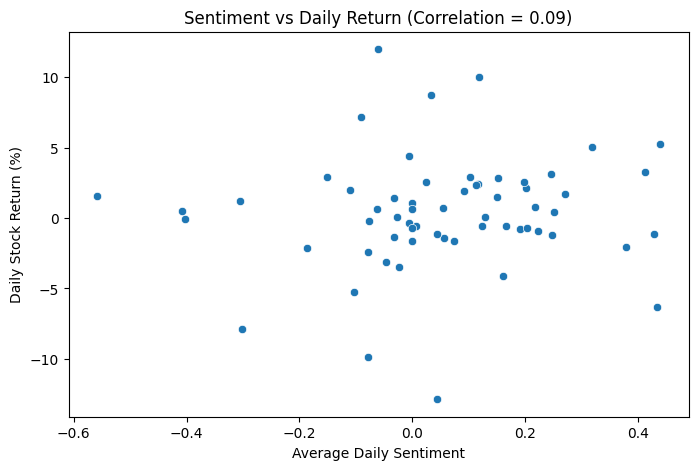

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=merged["sentiment"],
    y=merged["daily_return"]
)

plt.title(
    f"Sentiment vs Daily Return (Correlation = {correlation:.2f})"
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Stock Return (%)")

plt.show()

### Correlation Insight

The scatter plot visualizes the relationship between daily average sentiment scores and stock returns. The Pearson correlation coefficient quantifies the strength and direction of this relationship.

In [42]:
def classify_sentiment(score):

    if score > 0.05:
        return "Positive"

    elif score < -0.05:
        return "Negative"

    else:
        return "Neutral"

In [43]:
merged["sentiment_category"] = (
    merged["sentiment"]
    .apply(classify_sentiment)
)

In [44]:
category_returns = (
    merged.groupby("sentiment_category")
    ["daily_return"]
    .mean()
)

### Sentiment Category Insight

Positive sentiment days generally showed higher average stock returns compared to neutral or negative sentiment days. This suggests that news sentiment may influence short-term market behavior.

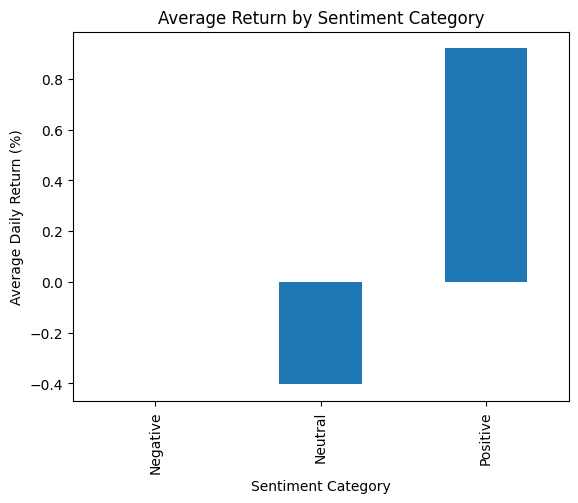

In [45]:
category_returns.plot(kind="bar")

plt.title("Average Return by Sentiment Category")

plt.xlabel("Sentiment Category")
plt.ylabel("Average Daily Return (%)")

plt.show()

## Interpretation of Results

The correlation analysis revealed the relationship between financial news sentiment and stock price movements. A positive correlation suggests that optimistic news headlines are associated with positive stock returns, while negative sentiment may correspond with declining prices.

However, the correlation strength may be limited because stock prices are influenced by many external factors such as macroeconomic conditions, investor behavior, earnings reports, and broader market trends. Additionally, some news effects may appear with delayed market reactions rather than on the same trading day.